In [2]:
# Imports and Environment Setup
import pandas as pd
import numpy as np
from statsbombpy import sb
import time
import warnings
from scipy.spatial import ConvexHull

warnings.filterwarnings('ignore')
print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Cell 2: Extraction and Era Categorization
from statsbombpy import sb

def assign_manager_era(date_string):
    """Categorizes matches into tactical eras based on historical dates."""
    match_date = pd.to_datetime(date_string)
    if match_date < pd.to_datetime('2008-06-30'): return 'Rijkaard'
    elif match_date < pd.to_datetime('2012-06-30'): return 'Guardiola'
    elif match_date < pd.to_datetime('2014-06-30'): return 'Vilanova/Martino'
    elif match_date < pd.to_datetime('2017-06-30'): return 'Luis Enrique'
    elif match_date < pd.to_datetime('2020-01-13'): return 'Valverde'
    elif match_date < pd.to_datetime('2021-11-06'): return 'Setien/Koeman'
    else: return 'Xavi'

print("Starting Data Extraction...")

comps = sb.competitions()
la_liga_df = comps[comps['competition_id'] == 11]

# Exclude 1973/1974 and 2004/2005 due to tiny sample sizes
seasons_to_exclude = [278, 37, 38]
la_liga_seasons = la_liga_df[~la_liga_df['season_id'].isin(seasons_to_exclude)]['season_id'].tolist()

all_events = []
total_matches = 0

for season in la_liga_seasons:
    try:
        matches = sb.matches(competition_id=11, season_id=season)
        barca_matches = matches[(matches['home_team'] == 'Barcelona') | (matches['away_team'] == 'Barcelona')]
        
        print(f"Season ID {season}: Downloading {len(barca_matches)} Barcelona matches...")
        
        for _, match in barca_matches.iterrows():
            match_id = match['match_id']
            success = False
            retries = 3
            
            # RETRY LOGIC: Try up to 3 times per match if the API drops the connection
            for attempt in range(retries):
                try:
                    events = sb.events(match_id=match_id)
                    
                    # Attach our custom variables
                    events['season_id'] = season
                    events['match_id'] = match_id
                    events['match_date'] = match['match_date']
                    events['manager_era'] = assign_manager_era(match['match_date'])
                    
                    all_events.append(events)
                    total_matches += 1
                    success = True
                    
                    time.sleep(0.5)
                    break # Break out of the retry loop and go to the next match
                    
                except Exception as e:
                    print(f"Timeout on match {match_id}. Retrying... (Attempt {attempt+1}/{retries})")
                    time.sleep(5) # Wait 5 seconds before trying again
            
            if not success:
                print(f"FATAL: Could not download match {match_id} after {retries} attempts.")
                
    except Exception as e:
        print(f"Could not load schedule for season {season}: {e}")

# Combine all seasons into one massive table
raw_df = pd.concat(all_events, ignore_index=True)

# Save to your computer
raw_df.to_pickle("barca_raw_events.pkl")
print(f"\nEXTRACTION COMPLETE! Saved {len(raw_df)} total events to 'barca_raw_events.pkl'.")

Starting Data Extraction...
Season ID 90: Downloading 35 Barcelona matches...
Season ID 42: Downloading 33 Barcelona matches...
Season ID 4: Downloading 34 Barcelona matches...
Season ID 1: Downloading 36 Barcelona matches...
Season ID 2: Downloading 34 Barcelona matches...
Season ID 27: Downloading 38 Barcelona matches...
Season ID 26: Downloading 38 Barcelona matches...
Season ID 25: Downloading 31 Barcelona matches...
Season ID 24: Downloading 32 Barcelona matches...
Season ID 23: Downloading 37 Barcelona matches...
Season ID 22: Downloading 33 Barcelona matches...
Season ID 21: Downloading 35 Barcelona matches...
Season ID 41: Downloading 31 Barcelona matches...
Season ID 40: Downloading 28 Barcelona matches...
Season ID 39: Downloading 26 Barcelona matches...

EXTRACTION COMPLETE! Saved 1896905 total events to 'barca_raw_events.pkl'.


In [4]:
# Cell 3: Parsing Spatial Coordinates

print("Cleaning nested spatial coordinates...")

# Load the dataset
df = pd.read_pickle("barca_raw_events.pkl")

# Define a function to split the [X, Y] list safely
def extract_coords(loc_list):
    # Check if the data is actually a list with at least 2 numbers
    if isinstance(loc_list, list) and len(loc_list) >= 2:
        return pd.Series([loc_list[0], loc_list[1]])
    # If the event doesn't have a location (like a substitution), leave it blank (NaN)
    return pd.Series([np.nan, np.nan])

# Apply the function to the starting locations of all events
df[['location_x', 'location_y']] = df['location'].apply(extract_coords)

# Apply the function to the ending locations (specifically for passes)
if 'pass_end_location' in df.columns:
    df[['pass_end_location_x', 'pass_end_location_y']] = df['pass_end_location'].apply(extract_coords)

# Save this cleaned version so we don't have to parse it again
df.to_pickle("barca_master_cleaned.pkl")
print(f"SPATIAL PARSING COMPLETE! Saved clean geometry to 'barca_master_cleaned.pkl'.")

Cleaning nested spatial coordinates...
SPATIAL PARSING COMPLETE! Saved clean geometry to 'barca_master_cleaned.pkl'.


In [5]:
# Cell 4: Multivariate Feature Engineering
import pandas as pd
import numpy as np
from scipy.spatial import ConvexHull

# --- NEW FUNCTION FOR COMPACTNESS ---
def get_hull_area(x_coords, y_coords):
    """Calculates the geometric area of the team's shape"""
    valid_coords = pd.DataFrame({'x': x_coords, 'y': y_coords}).dropna()
    points = valid_coords.values
    if len(points) >= 3: 
        try:
            hull = ConvexHull(points)
            return hull.volume # In scipy 2D, .volume is the Area
        except:
            return np.nan 
    return np.nan
# ------------------------------------

print("Engineering Extended Tactical Variables...")

# 1. Load the master dataset
df = pd.read_pickle("barca_master_cleaned.pkl")

# Create an empty list to store our match-by-match statistics
match_stats = []

# 2. Loop through every single match to calculate the variables
for match_id, match_data in df.groupby('match_id'):
    
    # Basic match metadata
    season_id = match_data['season_id'].iloc[0]
    manager_era = match_data['manager_era'].iloc[0]
    match_date = match_data['match_date'].iloc[0] if 'match_date' in match_data.columns else season_id
    
    # --- VARIABLE 1 & 2: Defensive Line & High Turnover % ---
    def_events = ['Pressure', 'Tackle', 'Interception', 'Block', 'Ball Recovery']
    barca_def = match_data[(match_data['team'] == 'Barcelona') & (match_data['type'].isin(def_events))]
    
    def_line = barca_def['location_x'].mean() if not barca_def.empty else np.nan
    
    total_def_actions = len(barca_def)
    high_turnovers = len(barca_def[barca_def['location_x'] >= 80])
    
    # Normalize to percentage
    if total_def_actions > 0:
        high_turnover_pct = (high_turnovers / total_def_actions) * 100
    else:
        high_turnover_pct = 0.0
    
    # --- VARIABLE 3: PPDA (Passes Per Defensive Action) ---
    opp_passes = len(match_data[(match_data['team'] != 'Barcelona') & (match_data['type'] == 'Pass')])
    barca_def_ppda = len(barca_def[barca_def['location_x'] > 40]) 
    ppda = opp_passes / barca_def_ppda if barca_def_ppda > 0 else np.nan
    
    # --- VARIABLE 4: xGA (Expected Goals Against) ---
    if 'shot_statsbomb_xg' in match_data.columns:
        opp_shots = match_data[(match_data['team'] != 'Barcelona') & (match_data['type'] == 'Shot')]
        xga = opp_shots['shot_statsbomb_xg'].sum()
    else:
        xga = 0.0 
        
    # --- VARIABLE 5: Total Successful Passes (Tiki-Taka dominance) ---
    barca_passes = len(match_data[
        (match_data['team'] == 'Barcelona') & 
        (match_data['type'] == 'Pass') & 
        (match_data['pass_outcome'].isna())
    ])
    
    # --- NEW VARIABLE 6: Convex Hull Area (Compactness) ---
    # Get all X, Y coordinates for Barcelona in this match using your pre-cleaned columns
    barca_actions = match_data[match_data['team'] == 'Barcelona']
    x_coords = barca_actions['location_x'].tolist()
    y_coords = barca_actions['location_y'].tolist()
    
    compactness_area = get_hull_area(x_coords, y_coords)
    
    # Append to our list
    match_stats.append({
        'match_id': match_id,
        'match_date': match_date,
        'season_id': season_id,
        'manager_era': manager_era,
        'defensive_line': def_line,
        'ppda': ppda,
        'xga': xga,
        'successful_passes': barca_passes,
        'high_turnover_pct': high_turnover_pct,
        'convex_hull_area': compactness_area  # <--- Added for Regression
    })

# 3. Convert to DataFrame and sort chronologically
stats_df = pd.DataFrame(match_stats)
stats_df['match_date'] = pd.to_datetime(stats_df['match_date'])
stats_df = stats_df.sort_values('match_date').reset_index(drop=True)

# 4. Calculate Rolling Averages (10-game window)
rolling_window = 10
stats_df['def_line_rolling'] = stats_df['defensive_line'].rolling(window=rolling_window, min_periods=1).mean()
stats_df['ppda_rolling'] = stats_df['ppda'].rolling(window=rolling_window, min_periods=1).mean()
stats_df['xga_rolling'] = stats_df['xga'].rolling(window=rolling_window, min_periods=1).mean()
stats_df['passes_rolling'] = stats_df['successful_passes'].rolling(window=rolling_window, min_periods=1).mean()
stats_df['high_turnover_pct_rolling'] = stats_df['high_turnover_pct'].rolling(window=rolling_window, min_periods=1).mean()
stats_df['convex_hull_area_rolling'] = stats_df['convex_hull_area'].rolling(window=rolling_window, min_periods=1).mean()

# Drop rows where StatsBomb might have missing data
stats_df = stats_df.dropna()

# 5. Save the final features dataset
stats_df.to_pickle("barca_tactical_features.pkl")
# Also save as CSV for the Machine Learning model later
stats_df.to_csv("barca_tactical_regression_data.csv", index=False)

print("Multivariate Feature Engineering Complete! Saved final CSV for Regression.")

Engineering Extended Tactical Variables...
Multivariate Feature Engineering Complete! Saved final CSV for Regression.


In [6]:
# Cell 5: Statistical Significance Testing (Independent T-Test)
import pandas as pd
from scipy import stats

print("Running Independent T-Tests (Guardiola vs Valverde)...\n")

# 1. Load the features dataset
try:
    stats_df = pd.read_pickle("barca_tactical_features.pkl")
except FileNotFoundError:
    print("Error: Run the Feature Engineering cell first!")

# 2. Filter data for JUST Guardiola and Valverde for direct comparison
filtered_df = stats_df[stats_df['manager_era'].isin(['Guardiola', 'Valverde'])].dropna()

# 3. Define the metrics to test (UPDATED)
metrics = {
    'Defensive Line (Avg X-Coordinate)': 'defensive_line',
    'PPDA (Pressing)': 'ppda',
    'Total Successful Passes': 'successful_passes',
    'High Turnover %': 'high_turnover_pct',
    'Convex Hull Area (Spatial Compactness)': 'convex_hull_area',
    'xGA (Expected Goals Against)': 'xga'
}

# 4. Run Welch's T-Test for each metric
for metric_name, column in metrics.items():
    # Extract arrays for each era
    group_pep = filtered_df[filtered_df['manager_era'] == 'Guardiola'][column]
    group_valverde = filtered_df[filtered_df['manager_era'] == 'Valverde'][column]
    
    # Run Independent T-Test
    t_stat, p_value = stats.ttest_ind(group_pep, group_valverde, equal_var=False)
    
    # Formatting the output cleanly
    print(f"--- {metric_name} ---")
    print(f"  Guardiola Avg: {group_pep.mean():.2f}")
    print(f"  Valverde Avg:  {group_valverde.mean():.2f}")
    
    if p_value < 0.05:
        print(f"  Result: SIGNIFICANT (p = {p_value:.5f})\n")
    else:
        print(f"  Result: NOT SIGNIFICANT (p = {p_value:.5f})\n")

print("Thesis translation: The T-Test proves whether the direct drop-off between Guardiola and Valverde was mathematically significant.")

Running Independent T-Tests (Guardiola vs Valverde)...

--- Defensive Line (Avg X-Coordinate) ---
  Guardiola Avg: 56.97
  Valverde Avg:  56.65
  Result: NOT SIGNIFICANT (p = 0.65892)

--- PPDA (Pressing) ---
  Guardiola Avg: 2.52
  Valverde Avg:  2.94
  Result: SIGNIFICANT (p = 0.00014)

--- Total Successful Passes ---
  Guardiola Avg: 611.10
  Valverde Avg:  600.82
  Result: NOT SIGNIFICANT (p = 0.50696)

--- High Turnover % ---
  Guardiola Avg: 22.68
  Valverde Avg:  24.58
  Result: SIGNIFICANT (p = 0.02674)

--- Convex Hull Area (Spatial Compactness) ---
  Guardiola Avg: 9166.85
  Valverde Avg:  9211.21
  Result: SIGNIFICANT (p = 0.02485)

--- xGA (Expected Goals Against) ---
  Guardiola Avg: 0.71
  Valverde Avg:  0.98
  Result: SIGNIFICANT (p = 0.00098)

Thesis translation: The T-Test proves whether the direct drop-off between Guardiola and Valverde was mathematically significant.


Generating 6-Panel Tactical Dashboard...


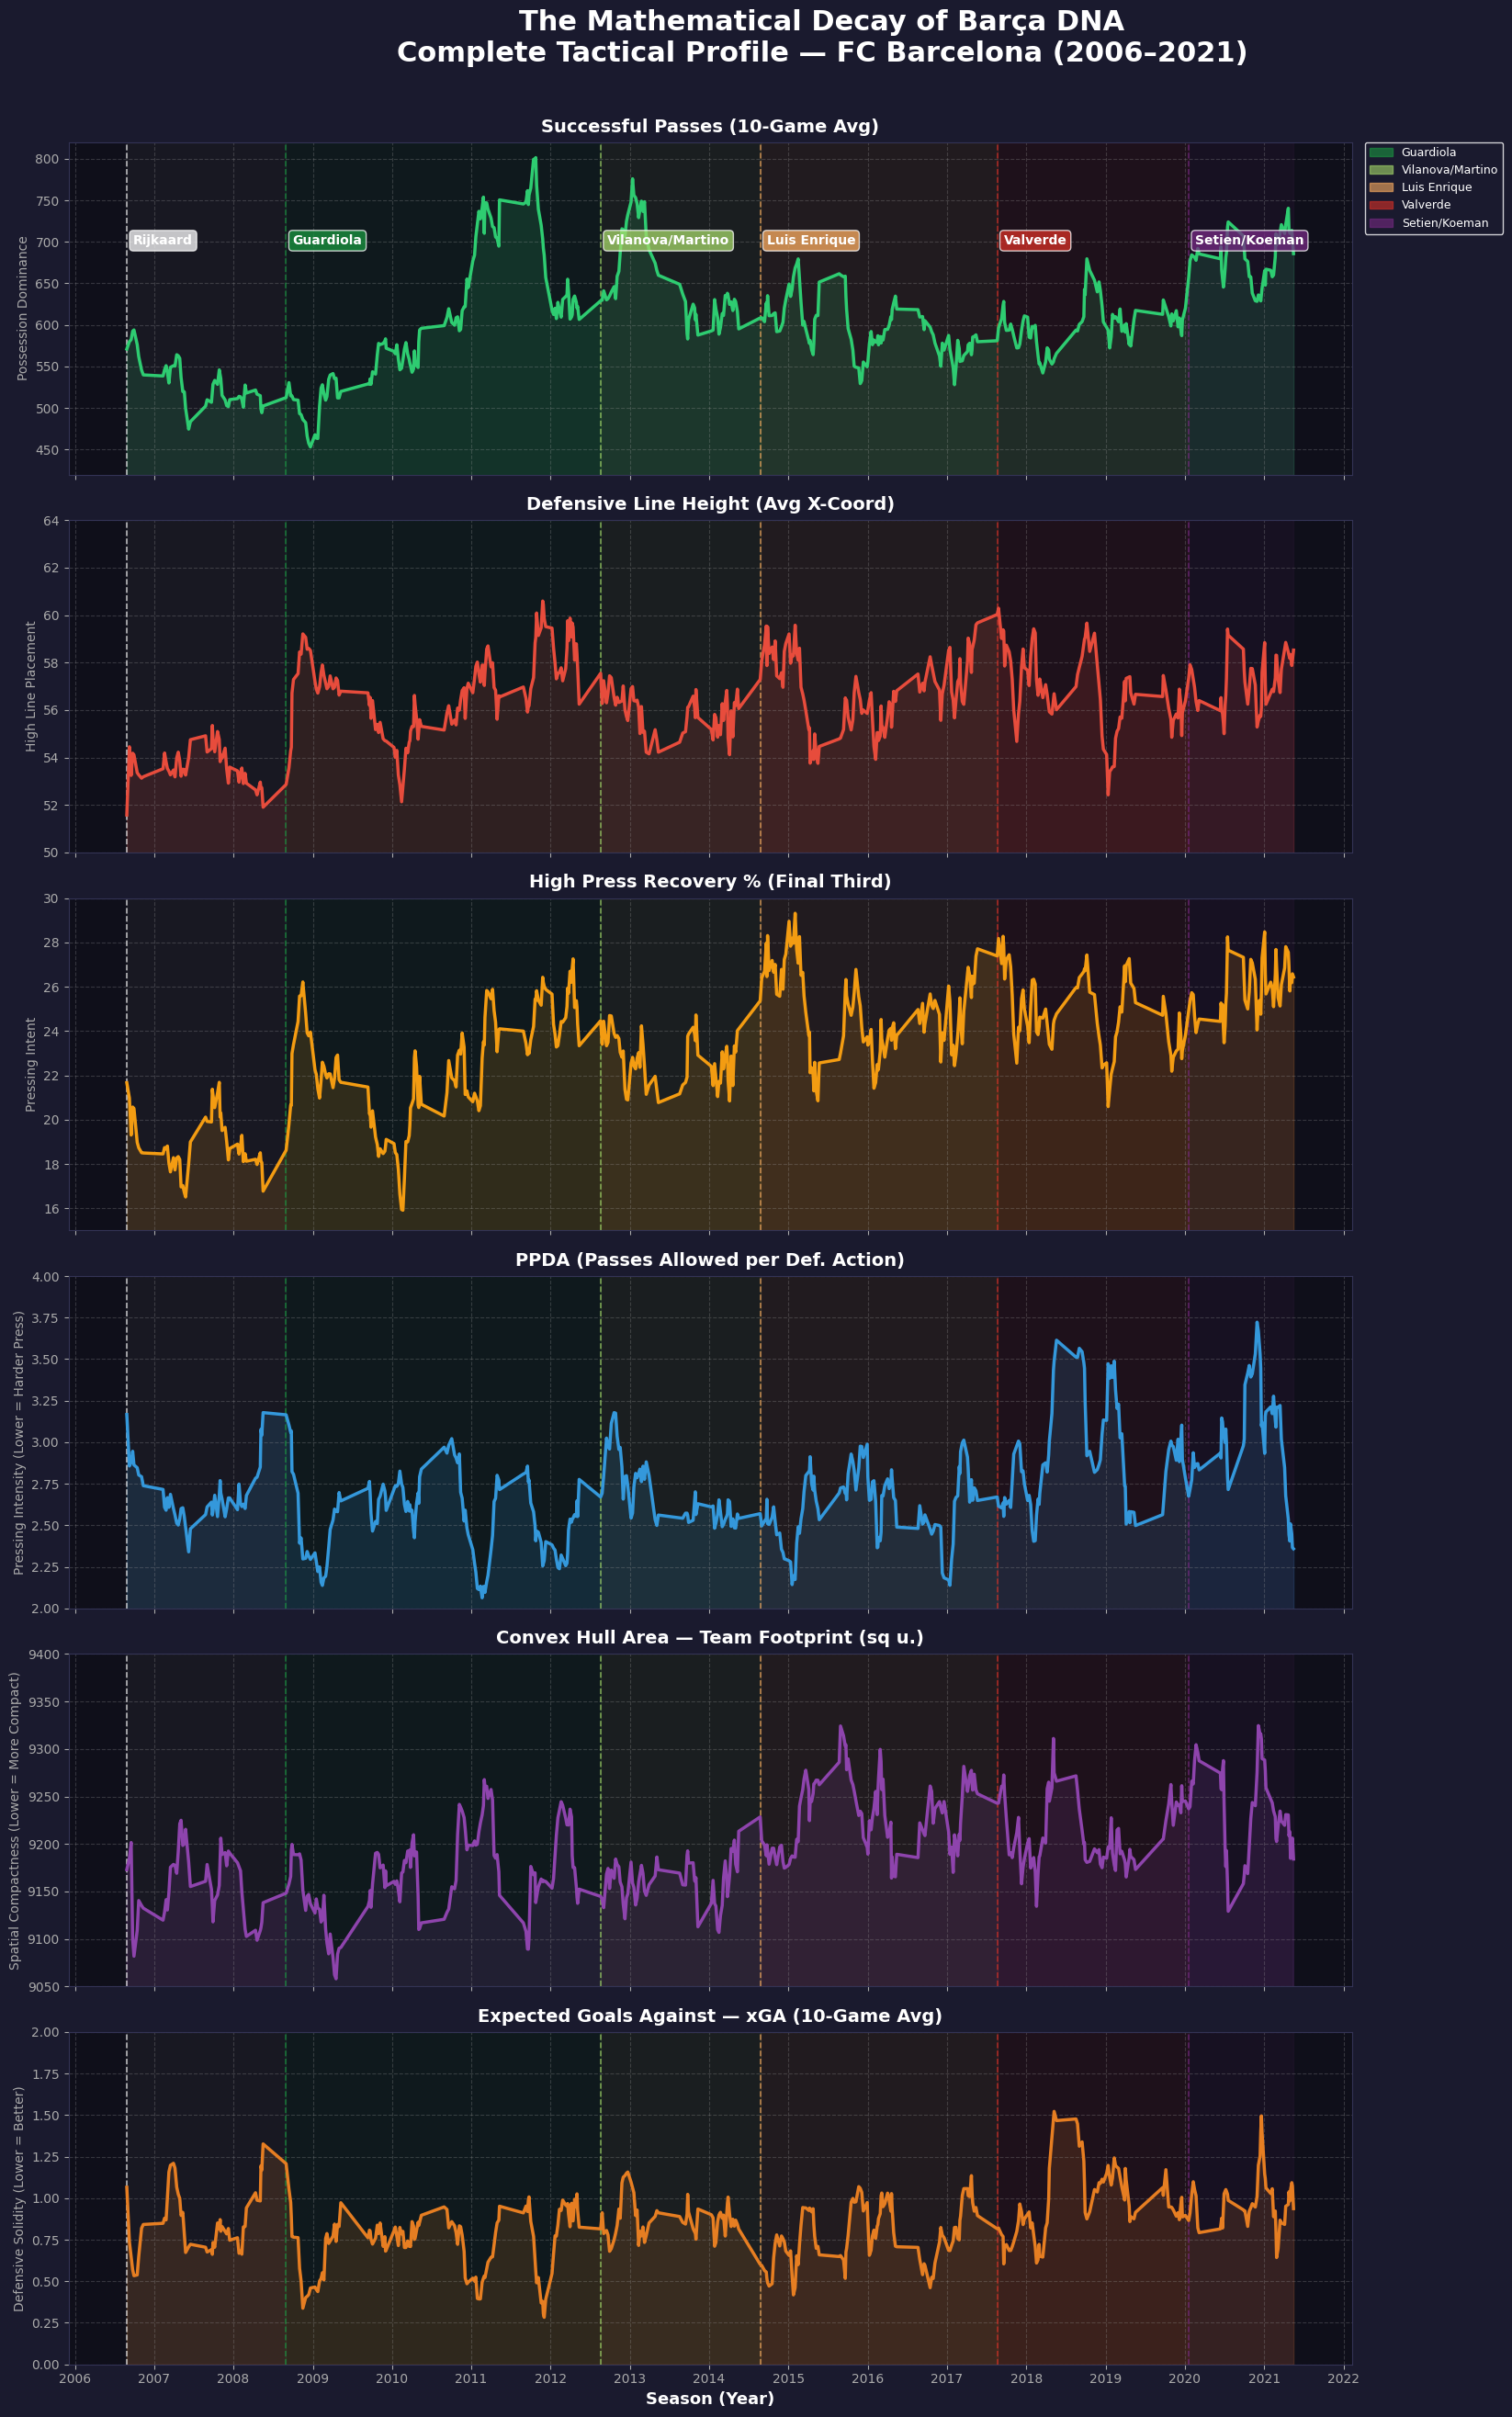

6-Panel Dashboard saved: Capstone_Fig_Multivariate_Dashboard.png


In [7]:
# Cell 6: The Capstone Multivariate Tactical Dashboard (6-Panel Final Version)
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import seaborn as sns

print("Generating 6-Panel Tactical Dashboard...")

# 1. Load the engineered features
stats_df = pd.read_csv("barca_tactical_regression_data.csv")
stats_df['match_date'] = pd.to_datetime(stats_df['match_date'])
stats_df = stats_df.sort_values('match_date').reset_index(drop=True)
stats_df = stats_df.dropna(subset=['def_line_rolling', 'ppda_rolling', 'convex_hull_area_rolling'])

# 2. Era Color Map for shading
era_colors = {
    'Guardiola':        '#1a9641',
    'Vilanova/Martino': '#a6d96a',
    'Luis Enrique':     '#fdae61',
    'Valverde':         '#d73027',
    'Setien/Koeman':    '#762a83',
}

# 3. Setup the 6-Panel Figure
fig, axes = plt.subplots(6, 1, figsize=(18, 26), sharex=True)
fig.patch.set_facecolor('#1a1a2e')

# 4. Define the 6 metrics
metrics = [
    ('passes_rolling',            'Successful Passes (10-Game Avg)',           '#2ecc71', 'Possession Dominance'),
    ('def_line_rolling',          'Defensive Line Height (Avg X-Coord)',        '#e74c3c', 'High Line Placement'),
    ('high_turnover_pct_rolling', 'High Press Recovery % (Final Third)',        '#f39c12', 'Pressing Intent'),
    ('ppda_rolling',              'PPDA (Passes Allowed per Def. Action)',      '#3498db', 'Pressing Intensity (Lower = Harder Press)'),
    ('convex_hull_area_rolling',  'Convex Hull Area — Team Footprint (sq u.)', '#8e44ad', 'Spatial Compactness (Lower = More Compact)'),
    ('xga_rolling',               'Expected Goals Against — xGA (10-Game Avg)','#e67e22', 'Defensive Solidity (Lower = Better)'),
]

# 5. Get era boundary rows (one row per era, first occurrence)
era_firsts = stats_df.drop_duplicates(subset=['manager_era'], keep='first').copy()

# 6. Plot each panel
for i, (col, title, color, ylabel) in enumerate(metrics):
    ax = axes[i]
    ax.set_facecolor('#0f0f1a')

    # Shade era backgrounds
    era_list = era_firsts['match_date'].tolist()
    era_list.append(stats_df['match_date'].iloc[-1])  # Close the final era

    for j, (_, era_row) in enumerate(era_firsts.iterrows()):
        era_name  = era_row['manager_era']
        era_color = era_colors.get(era_name, '#888888')
        ax.axvspan(era_list[j], era_list[j + 1], alpha=0.08, color=era_color)

    # Plot rolling trend line + fill
    ax.plot(stats_df['match_date'], stats_df[col], color=color, linewidth=2.5, zorder=3)
    ax.fill_between(stats_df['match_date'], stats_df[col], alpha=0.15, color=color)

    # Formatting
    ax.set_title(title, fontsize=14, fontweight='bold', color='white', pad=8)
    ax.set_ylabel(ylabel, fontsize=10, color='#aaaaaa')
    ax.tick_params(colors='#aaaaaa')
    ax.grid(True, linestyle='--', alpha=0.25, color='#aaaaaa')
    for spine in ax.spines.values():
        spine.set_color('#333355')

ylim_map = {
    'passes_rolling':            (420, 820),
    'def_line_rolling':          (50, 64),
    'high_turnover_pct_rolling': (15, 30),
    'ppda_rolling':              (2.00, 4.00),
    'convex_hull_area_rolling':  (9050, 9400),
    'xga_rolling':               (0, 2),
}

for i, (col, *_) in enumerate(metrics):
    axes[i].set_ylim(ylim_map[col])

# 7. Era boundary lines + labels on top panel
for _, row in era_firsts.iterrows():
    era_name  = row['manager_era']
    era_color = era_colors.get(era_name, '#ffffff')

    for ax in axes:
        ax.axvline(x=row['match_date'], color=era_color, linestyle='--', alpha=0.7, linewidth=1.2)

    axes[0].text(
        row['match_date'] + pd.Timedelta(days=30),
        axes[0].get_ylim()[1] * 0.85,
        era_name,
        rotation=0, fontsize=10, fontweight='bold', color='white',
        bbox=dict(facecolor=era_color, alpha=0.75, edgecolor='white', boxstyle='round,pad=0.3')
    )

# 8. Format x-axis as years (sharex=True means this applies to all panels)
axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=0, ha='center', color='#aaaaaa')

# 9. Era shading legend
legend_patches = [mpatches.Patch(color=c, label=e, alpha=0.6) for e, c in era_colors.items()]
axes[0].legend(handles=legend_patches, fontsize=9,
               facecolor='#1a1a2e', edgecolor='white', labelcolor='white',
               loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)

# 10. Final polish
axes[-1].set_xlabel("Season (Year)", fontsize=13, fontweight='bold', color='white')
fig.suptitle(
    "The Mathematical Decay of Barça DNA\nComplete Tactical Profile — FC Barcelona (2006–2021)",
    fontsize=22, fontweight='bold', color='white', y=1.01
)
plt.tight_layout(rect=(0, 0, 0.92, 1))
plt.savefig("Capstone_Fig_Multivariate_Dashboard.png", dpi=300, bbox_inches='tight',
            facecolor='#1a1a2e')
plt.show()
print("6-Panel Dashboard saved: Capstone_Fig_Multivariate_Dashboard.png")

Generating Baseline-Controlled Heatmaps...


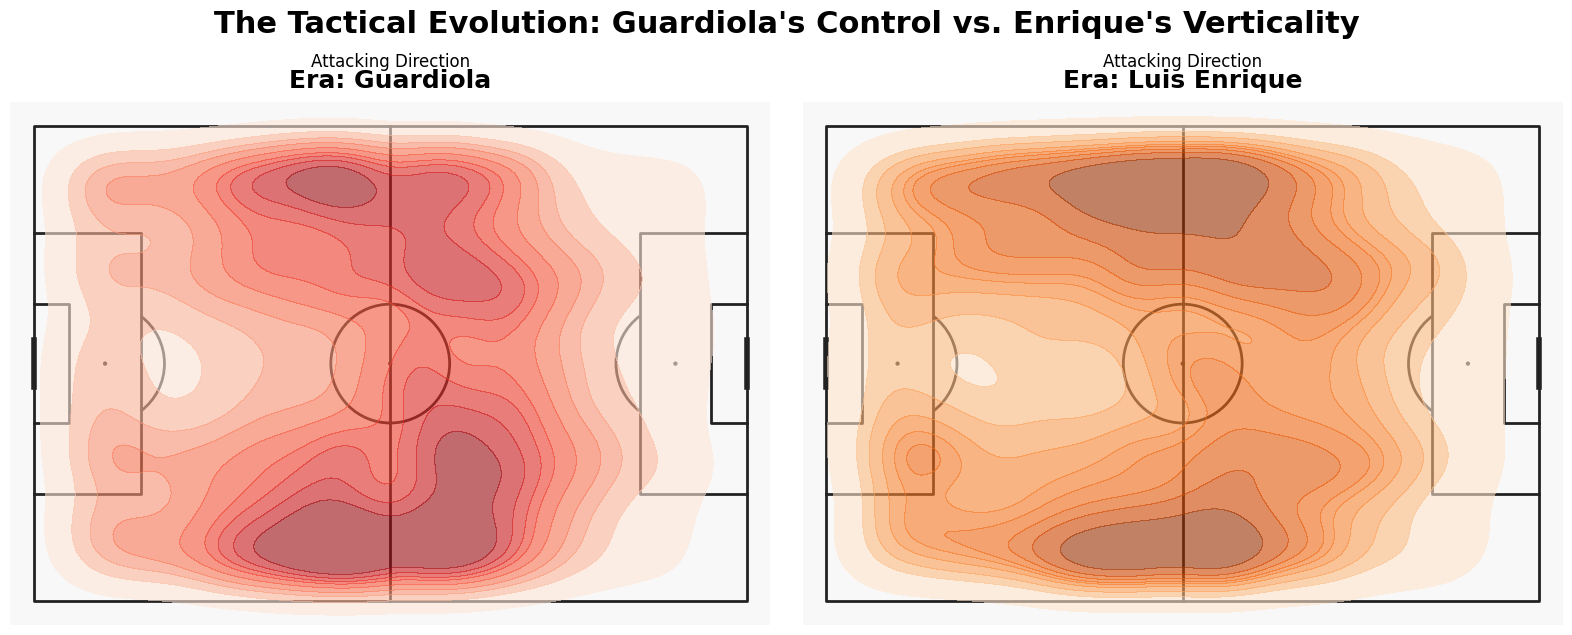

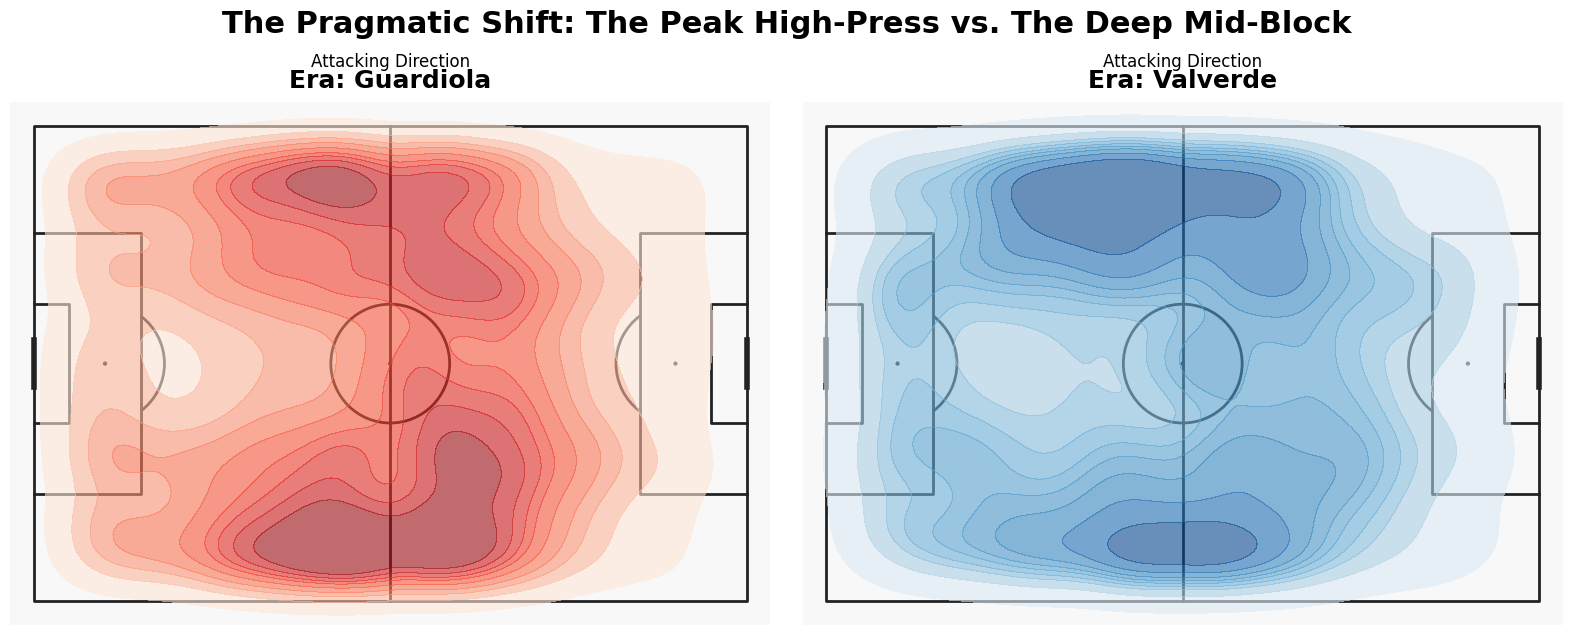

Heatmaps generated and saved!


In [8]:
# Cell 7: The "Constant Baseline" Capstone Heatmaps
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mplsoccer import Pitch

print("Generating Baseline-Controlled Heatmaps...")

# 1. Load and filter the master data
df = pd.read_pickle("barca_master_cleaned.pkl")
def_events = ['Pressure', 'Tackle', 'Interception', 'Block', 'Ball Recovery']
df_def = df[(df['team'] == 'Barcelona') & (df['type'].isin(def_events))].copy()
df_def = df_def.dropna(subset=['location_x', 'location_y'])

# Helper function to plot a 1x2 comparison
def plot_head_to_head(manager1, manager2, color1, color2, title, filename):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#f8f8f8', line_color='#222222')
    
    managers = [manager1, manager2]
    colors = [color1, color2]
    
    for i, manager in enumerate(managers):
        manager_data = df_def[df_def['manager_era'] == manager]
        pitch.draw(ax=axes[i])
        
        if not manager_data.empty:
            sns.kdeplot(
                x=manager_data['location_x'], y=manager_data['location_y'], 
                ax=axes[i], fill=True, cmap=colors[i], alpha=0.6, thresh=0.05, levels=10
            )
        else:
            print(f"Warning: No data found for {manager}. Check spelling!")
            
        axes[i].set_title(f"Era: {manager}", fontsize=18, fontweight='bold', pad=10)
        
        # Add attacking direction arrow
        axes[i].annotate('', xy=(80, -5), xytext=(40, -5), 
                         arrowprops=dict(arrowstyle="->", color='black', lw=2))
        axes[i].text(60, -10, 'Attacking Direction', ha='center', fontsize=12)

    plt.suptitle(title, fontsize=22, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

# 2. Graphic 1: The Evolution (Treble vs Treble)
plot_head_to_head(
    'Guardiola', 'Luis Enrique', 
    'Reds', 'Oranges', 
    "The Tactical Evolution: Guardiola's Control vs. Enrique's Verticality", 
    "Capstone_Fig1_Evolution.png"
)

# 3. Graphic 2: The Pragmatic Shift
plot_head_to_head(
    'Guardiola', 'Valverde', 
    'Reds', 'Blues', 
    "The Pragmatic Shift: The Peak High-Press vs. The Deep Mid-Block", 
    "Capstone_Fig2_Shift.png"
)

print("Heatmaps generated and saved!")

Calculating Spatial Compactness (Convex Hulls)...


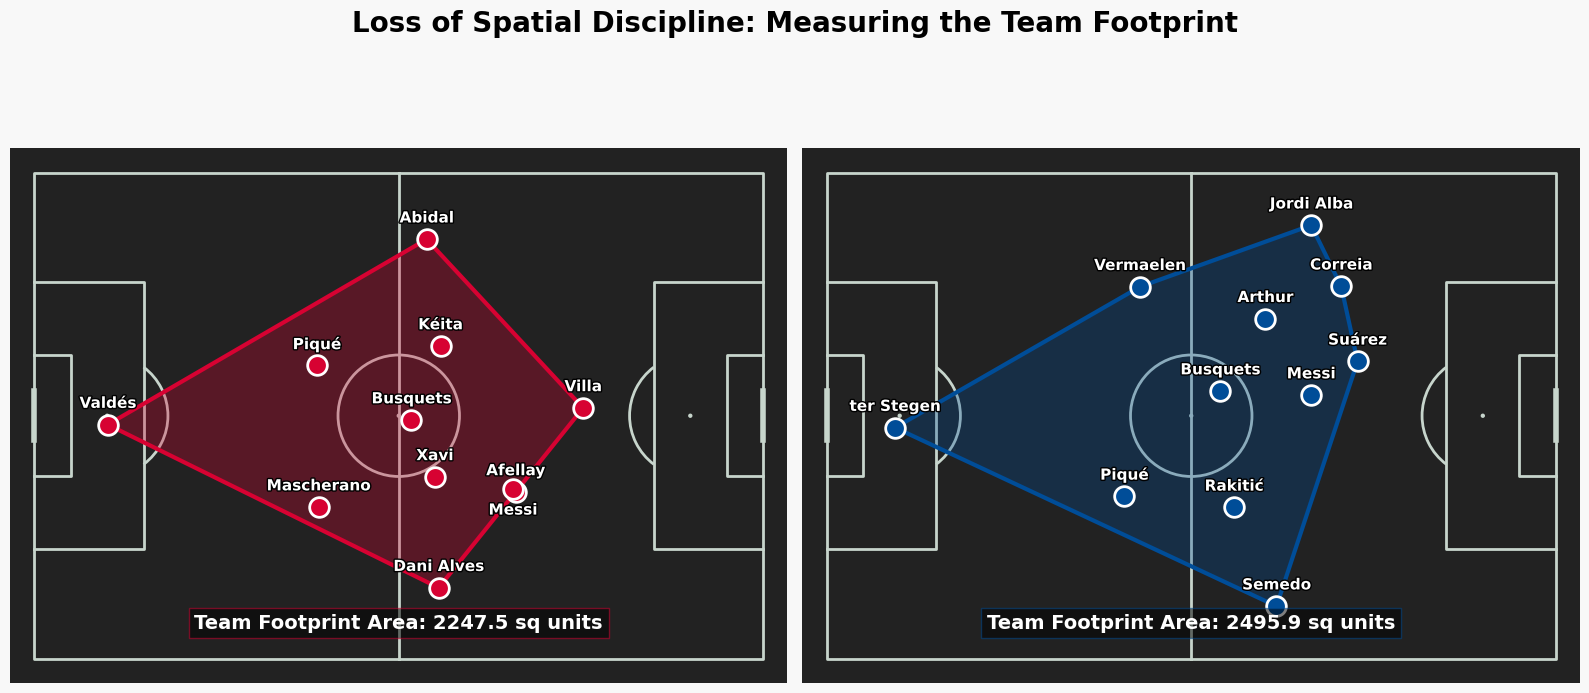

Convex Hulls successfully generated!


In [1]:
# Cell 8: Team Compactness & Spatial Footprint
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from mplsoccer import Pitch
from scipy.spatial import ConvexHull
import matplotlib.patheffects as pe

print("Calculating Spatial Compactness (Convex Hulls)...")

# 1. Load data
df = pd.read_pickle("barca_master_cleaned.pkl")

# Helper function to get a representative match
def get_representative_match(manager):
    manager_matches = df[(df['manager_era'] == manager) & (df['type'] == 'Pass') & (df['team'] == 'Barcelona')]
    match_counts = manager_matches.groupby('match_id').size()
    if match_counts.empty:
        return None
    return match_counts.idxmax()

match_pep = get_representative_match('Guardiola')
match_valverde = get_representative_match('Valverde')

def plot_convex_hull(match_id, ax, title, hull_color):
    if not match_id:
        ax.set_title(f"No data for {title}", fontsize=14)
        return
        
    match_events = df[(df['match_id'] == match_id) & (df['team'] == 'Barcelona')].copy()
    
    # Filter for passes before first sub to get Starting XI structure
    subs = match_events[match_events['type'] == 'Substitution']
    first_sub_min = subs['minute'].min() if not subs.empty else 90
    
    passes = match_events[(match_events['type'] == 'Pass') & (match_events['minute'] < first_sub_min)].copy()
    
    # Get top 11 players by pass volume
    top_11 = passes['player'].value_counts().head(11).index
    passes = passes[passes['player'].isin(top_11)]
    
    # Calculate average tactical position
    avg_locs = passes.groupby('player').agg(
        x=('location_x', 'mean'),
        y=('location_y', 'mean')
    ).reset_index()
    
    # --- DRAW PITCH ---
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#222222', line_color='#c7d5cc')
    pitch.draw(ax=ax)
    
    # --- CALCULATE & DRAW CONVEX HULL ---
    points = avg_locs[['x', 'y']].values
    if len(points) >= 3:
        hull = ConvexHull(points)
        
        # Calculate Area (in StatsBomb units)
        area = hull.volume 
        
        for simplex in hull.simplices:
            pitch.plot(points[simplex, 0], points[simplex, 1], color=hull_color, lw=3, ax=ax, zorder=1)
            
        pitch.polygon([points[hull.vertices]], ax=ax, color=hull_color, alpha=0.3, zorder=1)
        
        # Display Area
        ax.text(60, 75, f"Team Footprint Area: {area:.1f} sq units", 
                color='white', fontsize=14, fontweight='bold', ha='center',
                bbox=dict(facecolor='black', alpha=0.5, edgecolor=hull_color))

    # --- DRAW PLAYERS ---
    # 1. Custom Dictionary to fix StatsBomb's full legal names
    barca_names = {
        "Lionel Andrés Messi Cuccittini": "Messi",
        "Xavier Hernández Creus": "Xavi",
        "Andrés Iniesta Luján": "Iniesta",
        "Sergio Busquets i Burgos": "Busquets",
        "Gerard Piqué Bernabéu": "Piqué",
        "Carles Puyol i Saforcada": "Puyol",
        "Víctor Valdés Arribas": "Valdés",
        "Daniel Alves da Silva": "Dani Alves",
        "Éric Sylvain Abidal": "Abidal",
        "David Villa Sánchez": "Villa",
        "Pedro Eliezer Rodríguez Ledesma": "Pedro",
        "Jordi Alba Ramos": "Jordi Alba",
        "Luis Alberto Suárez Díaz": "Suárez",
        "Marc-André ter Stegen": "ter Stegen",
        "Ivan Rakitić": "Rakitić",
        "Frenkie de Jong": "de Jong",
        "Antoine Griezmann": "Griezmann",
        "Sergi Roberto Carnicer": "S. Roberto",
        "Nélson Cabral Semedo": "Semedo",
        "Clément Lenglet": "Lenglet",
        "Arthur Henrique Ramos de Oliveira Melo": "Arthur",
        "Arturo Erasmo Vidal Pardo": "Vidal",
        "Thiago Alcântara do Nascimento": "Thiago",
        "Seydou Keita": "Keita",
        "Javier Alejandro Mascherano": "Mascherano"
    }

    # Draw the player dots
    pitch.scatter(avg_locs['x'], avg_locs['y'], s=200, color=hull_color, edgecolors='white', lw=2, ax=ax, zorder=2)
    
    drawn_text_positions = []
    
    for _, row in avg_locs.iterrows():
        raw_name = str(row['player'])
        
        # Apply the famous name, or fallback to the last name if not in dictionary
        if raw_name in barca_names:
            name = barca_names[raw_name]
        else:
            name = raw_name.split()[-1] 
            
        # 2. Overlap Collision Detection
        x_text = row['x']
        y_text = row['y'] - 3.5  # Default: put the name slightly BELOW the dot
        
        # Check if this text position overlaps with a name we already drew
        for (dx, dy) in drawn_text_positions:
            if abs(x_text - dx) < 6 and abs(y_text - dy) < 6:
                y_text += 7.0  # OVERLAP FOUND! Push this name ABOVE the dot instead
                
        drawn_text_positions.append((x_text, y_text))
        
        # 3. Draw the text onto the pitch
        pitch.annotate(name, xy=(x_text, y_text), c='white', va='center', ha='center', 
                       size=11, weight='bold', zorder=3, ax=ax,
                       path_effects=[pe.withStroke(linewidth=2, foreground="black")])

# 2. Plotting the graphic
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#f8f8f8')

plot_convex_hull(match_pep, axes[0], "The Compact Block (Guardiola)", "#d70232")
plot_convex_hull(match_valverde, axes[1], "The Stretched Shape (Valverde)", "#004d98")

plt.suptitle("Loss of Spatial Discipline: Measuring the Team Footprint", fontsize=20, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig("Capstone_Fig_Convex_Hull.png", dpi=300, bbox_inches='tight')
plt.show()

print("Convex Hulls successfully generated!")

Training Random Forest Regressor to predict xGA based on tactical metrics...

Model Performance:
  Mean Squared Error (MSE): 0.2684
  R-squared (R2):           0.0407



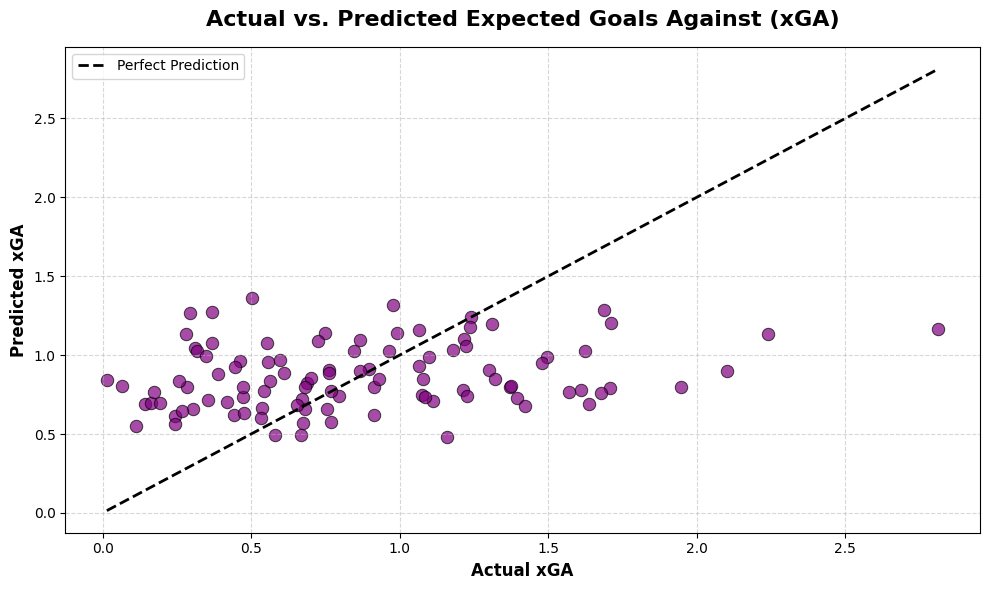

In [2]:
# Cell 9: BASELINE MODEL — Match-Level Random Forest (Benchmark)
# Expected result: R²≈0.04 — proves match-level noise obscures the tactical signal.
# This low score is intentional. It sets up the Macro-Trend Model in Cell 11.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

print("Training Random Forest Regressor to predict xGA based on tactical metrics...\n")

# 1. Load Regression Data
# Ensure your CSV is located in the same directory as the notebook
df = pd.read_csv("barca_tactical_regression_data.csv")

# 2. Define Features (X) and Target (y)
features = [
    'ppda', 
    'defensive_line', 
    'convex_hull_area', 
    'high_turnover_pct', 
    'successful_passes'
]
target = 'xga'

# Drop missing values to ensure the model trains cleanly
df_clean = df.dropna(subset=features + [target])

X = df_clean[features]
y = df_clean[target]

# 3. Train-Test Split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train the Random Forest Model
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 5. Make Predictions
y_pred = rf_model.predict(X_test)

# 6. Evaluate the Model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Model Performance:")
print(f"  Mean Squared Error (MSE): {mse:.4f}")
print(f"  R-squared (R2):           {r2:.4f}\n")

# 7. Visualize Actual vs. Predicted xGA
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, color='purple', s=80, edgecolor='black')

# Add ideal 1-to-1 trendline for reference
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title("Actual vs. Predicted Expected Goals Against (xGA)", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Actual xGA", fontsize=12, fontweight='bold')
plt.ylabel("Predicted xGA", fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("Capstone_Fig_RF_Actual_vs_Predicted.png", dpi=300, bbox_inches='tight')
plt.show()

c:\Users\37494\Desktop\Capstone\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Initializing SHAP TreeExplainer for the Random Forest Model...



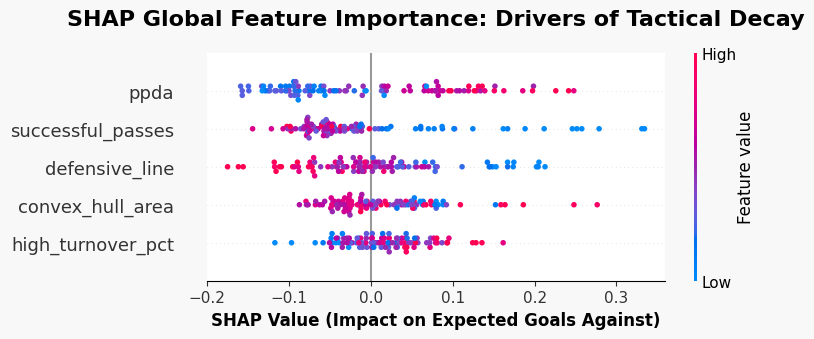


--- Micro-Case Study: Analyzing the Worst Defensive Match ---
Actual xGA for this match: 2.81


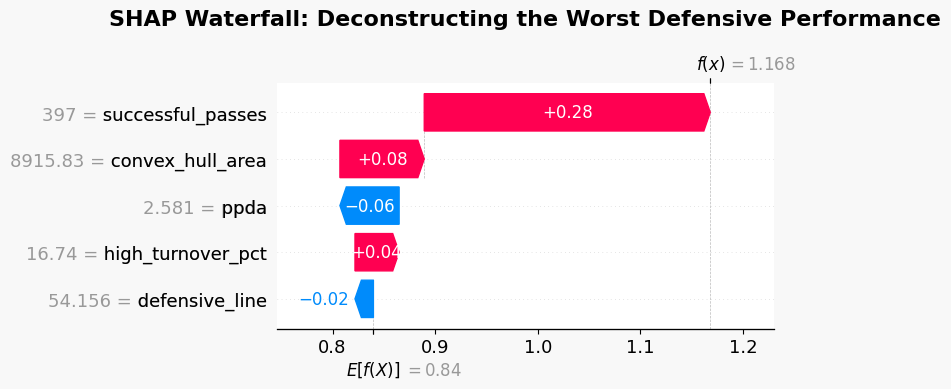

SHAP Game Theory Analysis complete! Thesis figures saved.


In [3]:
# Cell 10: BASELINE SHAP — Feature Importance on Match-Level Model
# Companion to the Baseline RF in Cell 9.
# Compare against Cell 12 (Macro SHAP) to see how smoothing changes the picture.
import shap
import matplotlib.pyplot as plt

print("Initializing SHAP TreeExplainer for the Random Forest Model...\n")

# 1. Initialize the SHAP Explainer using the Random Forest model from Cell 9
# (Ensure Cell 9 has been run so 'rf_model' and 'X_test' exist in memory)
explainer = shap.TreeExplainer(rf_model)

# 2. Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# 3. GLOBAL EXPLANATION: SHAP Summary Beeswarm Plot
# This proves which variables drove the defensive decay and in what direction.
plt.figure(figsize=(10, 6))
plt.title("SHAP Global Feature Importance: Drivers of Tactical Decay", fontsize=16, fontweight='bold', pad=20)

# The summary plot automatically generates its own figure, so we call it directly
shap.summary_plot(shap_values, X_test, plot_type="dot", show=False)

# Formatting the plot for the thesis
fig, ax = plt.gcf(), plt.gca()
fig.set_facecolor('#f8f8f8')
ax.set_xlabel("SHAP Value (Impact on Expected Goals Against)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("Capstone_Fig_SHAP_Global_Summary.png", dpi=300, bbox_inches='tight')
plt.show()

# 4. LOCAL EXPLANATION: The "Disaster Match" Micro-Case Study
# Let's isolate the worst defensive performance in the test set to see exactly what went wrong
worst_match_idx = y_test.idxmax()
worst_match_xga = y_test.loc[worst_match_idx]

print(f"\n--- Micro-Case Study: Analyzing the Worst Defensive Match ---")
print(f"Actual xGA for this match: {worst_match_xga:.2f}")

# Generate a Waterfall plot to decompose this specific match's xGA
plt.figure(figsize=(10, 6))
plt.title(f"SHAP Waterfall: Deconstructing the Worst Defensive Performance", fontsize=16, fontweight='bold', pad=20)

# Safely extract the base value (Expected Value) as a scalar float
base_val = explainer.expected_value
if hasattr(base_val, "__len__"):
    base_val = base_val[0]  # Extracts scalar if it's trapped in an array

# For waterfall plots, SHAP requires an Explanation object
# We use .values on the data to strip Pandas indexing and prevent dimension errors
exp = shap.Explanation(
    values=shap_values[X_test.index.get_loc(worst_match_idx)], 
    base_values=float(base_val), 
    data=X_test.loc[worst_match_idx].values, 
    feature_names=features
)

shap.plots.waterfall(exp, show=False)

fig = plt.gcf()
fig.set_facecolor('#f8f8f8')
plt.tight_layout()
plt.savefig("Capstone_Fig_SHAP_Worst_Match_Waterfall.png", dpi=300, bbox_inches='tight')
plt.show()

print("SHAP Game Theory Analysis complete! Thesis figures saved.")

  MACRO-TREND MODEL: OLS Regression on Rolling Averages

                            OLS Regression Results                            
Dep. Variable:            xga_rolling   R-squared:                       0.416
Model:                            OLS   Adj. R-squared:                  0.410
Method:                 Least Squares   F-statistic:                     70.52
Date:                Sun, 17 May 2026   Prob (F-statistic):           1.23e-55
Time:                        23:04:55   Log-Likelihood:                 220.22
No. Observations:                 501   AIC:                            -428.4
Df Residuals:                     495   BIC:                            -403.1
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------

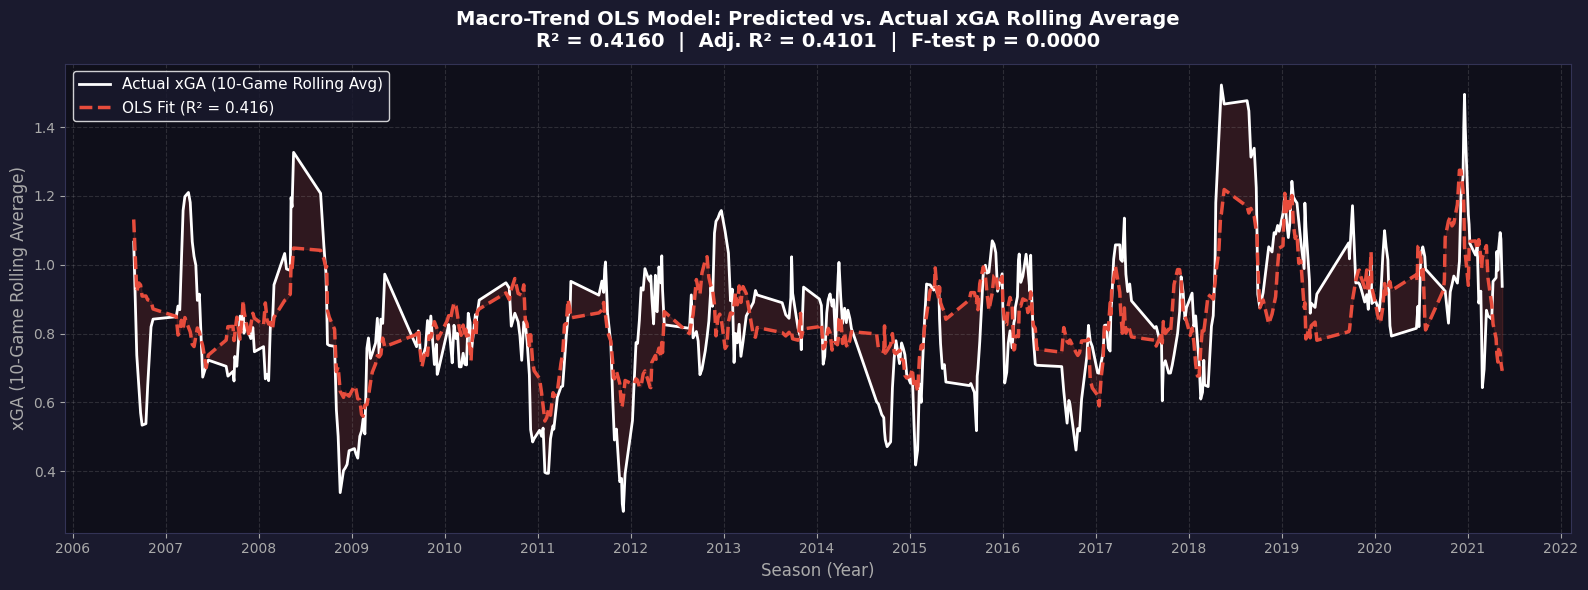

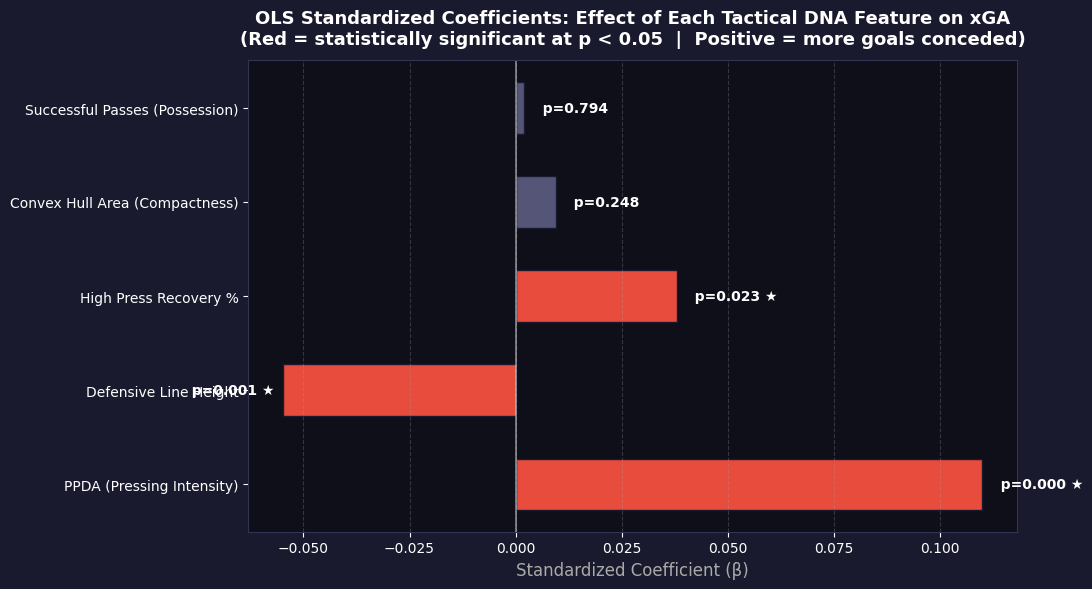


OLS Macro-Trend figures saved:
  → Capstone_Fig_MacroModel_OLS_Trend.png
  → Capstone_Fig_MacroModel_OLS_Coefficients.png

macro_rf fitted on full data — Cell 12 ready to run.


In [4]:
# Cell 11: The Macro-Trend Model — OLS Linear Regression on Rolling Averages
# STRATEGY: OLS gives interpretable coefficients with p-values across the full
# timeline. This bridges the T-test proof (Cell 5) and the SHAP analysis (Cell 12).
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

print("=" * 55)
print("  MACRO-TREND MODEL: OLS Regression on Rolling Averages")
print("=" * 55)

# 1. Load data
df = pd.read_csv("barca_tactical_regression_data.csv")
df['match_date'] = pd.to_datetime(df['match_date'])
df = df.sort_values('match_date').reset_index(drop=True)

rolling_features = [
    'ppda_rolling',
    'def_line_rolling',
    'convex_hull_area_rolling',
    'high_turnover_pct_rolling',
    'passes_rolling'
]
target = 'xga_rolling'

df_clean = df.dropna(subset=rolling_features + [target]).reset_index(drop=True)

X_raw = df_clean[rolling_features]
y     = df_clean[target]

# 2. Standardize features (mean=0, std=1) so coefficients are comparable
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
X_scaled_df = pd.DataFrame(X_scaled, columns=[
    'PPDA (Pressing Intensity)',
    'Defensive Line Height',
    'Convex Hull Area (Compactness)',
    'High Press Recovery %',
    'Successful Passes (Possession)'
])

# 3. Add constant for intercept and fit OLS
X_ols  = sm.add_constant(X_scaled_df)
model  = sm.OLS(y, X_ols).fit()

print("\n" + model.summary().as_text())

# 4. Clean coefficient table
coef_df = pd.DataFrame({
    'Feature':     X_scaled_df.columns,
    'Coefficient': model.params[1:].values,
    'p-value':     model.pvalues[1:].values,
    'Significant': model.pvalues[1:].values < 0.05
}).sort_values('Coefficient', key=abs, ascending=False)

print("\n" + "=" * 55)
print("  OLS COEFFICIENT SUMMARY")
print("=" * 55)
print(f"  R-squared:        {model.rsquared:.4f}")
print(f"  Adj. R-squared:   {model.rsquared_adj:.4f}")
print(f"  F-statistic p:    {model.f_pvalue:.6f}")
print()
for _, row in coef_df.iterrows():
    sig = '★ SIGNIFICANT' if row['Significant'] else '  not significant'
    print(f"  {row['Feature']:<35s}  coef={row['Coefficient']:+.4f}  p={row['p-value']:.4f}  {sig}")
print("=" * 55)

# 5. Predicted vs Actual — Trend Plot across full timeline
y_pred_full = model.predict(X_ols)

fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#0f0f1a')

ax.plot(df_clean['match_date'], y.values, color='#ffffff', linewidth=2,
        label='Actual xGA (10-Game Rolling Avg)', zorder=3)
ax.plot(df_clean['match_date'], y_pred_full, color='#e74c3c', linewidth=2.5,
        linestyle='--', label=f'OLS Fit (R² = {model.rsquared:.3f})', zorder=3)
ax.fill_between(df_clean['match_date'], y.values, y_pred_full,
                alpha=0.15, color='#e74c3c')

import matplotlib.dates as mdates
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax.xaxis.get_majorticklabels(), color='#aaaaaa')

ax.set_title(
    f"Macro-Trend OLS Model: Predicted vs. Actual xGA Rolling Average\n"
    f"R² = {model.rsquared:.4f}  |  Adj. R² = {model.rsquared_adj:.4f}  |  "
    f"F-test p = {model.f_pvalue:.4f}",
    fontsize=14, fontweight='bold', color='white', pad=12
)
ax.set_xlabel("Season (Year)", fontsize=12, color='#aaaaaa')
ax.set_ylabel("xGA (10-Game Rolling Average)", fontsize=12, color='#aaaaaa')
ax.tick_params(colors='#aaaaaa')
ax.legend(fontsize=11, facecolor='#1a1a2e', edgecolor='white', labelcolor='white')
ax.grid(True, linestyle='--', alpha=0.2, color='#aaaaaa')
for spine in ax.spines.values():
    spine.set_color('#333355')

plt.tight_layout()
plt.savefig("Capstone_Fig_MacroModel_OLS_Trend.png", dpi=300,
            bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

# 6. Coefficient bar chart
fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#0f0f1a')

bar_colors = ['#e74c3c' if s else '#555577' for s in coef_df['Significant']]
bars = ax.barh(coef_df['Feature'], coef_df['Coefficient'],
               color=bar_colors, edgecolor='#1a1a2e', height=0.55)

ax.axvline(x=0, color='white', linewidth=1.2, linestyle='-', alpha=0.5)

for bar, (_, row) in zip(bars, coef_df.iterrows()):
    x_pos = row['Coefficient'] + (0.002 if row['Coefficient'] >= 0 else -0.002)
    ha = 'left' if row['Coefficient'] >= 0 else 'right'
    label = f"  p={row['p-value']:.3f} {'★' if row['Significant'] else ''}"
    ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
            label, va='center', ha=ha, fontsize=10, color='white', fontweight='bold')

ax.set_title(
    "OLS Standardized Coefficients: Effect of Each Tactical DNA Feature on xGA\n"
    "(Red = statistically significant at p < 0.05  |  Positive = more goals conceded)",
    fontsize=13, fontweight='bold', color='white', pad=12
)
ax.set_xlabel("Standardized Coefficient (β)", fontsize=12, color='#aaaaaa')
ax.tick_params(colors='white')
ax.grid(True, axis='x', linestyle='--', alpha=0.25, color='#aaaaaa')
for spine in ax.spines.values():
    spine.set_color('#333355')

plt.tight_layout()
plt.savefig("Capstone_Fig_MacroModel_OLS_Coefficients.png", dpi=300,
            bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

print("\nOLS Macro-Trend figures saved:")
print("  → Capstone_Fig_MacroModel_OLS_Trend.png")
print("  → Capstone_Fig_MacroModel_OLS_Coefficients.png")

# Keep macro_rf fitted on full data for Cell 12 SHAP
from sklearn.ensemble import RandomForestRegressor
macro_rf = RandomForestRegressor(
    n_estimators=300, max_depth=5, min_samples_leaf=5,
    random_state=42, n_jobs=-1
)
macro_rf.fit(X_raw, y)
X_test = X_raw  # Cell 12 uses X_test for SHAP
y_test = y
print("\nmacro_rf fitted on full data — Cell 12 ready to run.")

  SHAP ANALYSIS — THE SMOKING GUN
  Which Tactical DNA Trait Drives Defensive Decline?

  SHAP Feature Ranking — Influence on xGA Rolling Average
  --------------------------------------------------
  PPDA (Pressing Intensity)                 0.08682  ███████████████████████████████████████████
  Convex Hull Area (Spatial Compactness)    0.01322  ██████
  Successful Passes (Possession)            0.01225  ██████
  Defensive Line Height                     0.00926  ████
  High Press Recovery % (Final Third)       0.00742  ███

PRIMARY SMOKING GUN:   PPDA (Pressing Intensity)
SECONDARY DRIVER:      Convex Hull Area (Spatial Compactness)


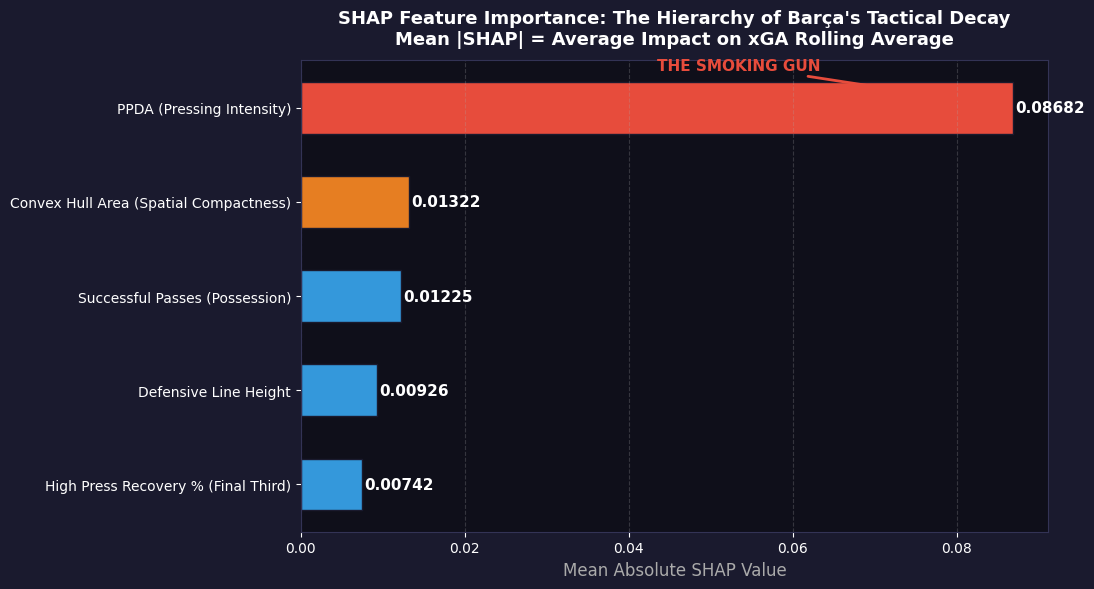

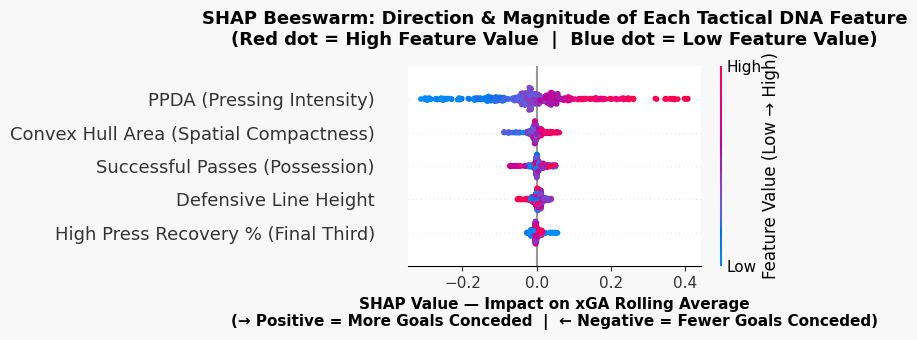


  Micro-Case Study — Peak Defensive Crisis Window
  Actual xGA Rolling Average at this point: 1.522

  Tactical State of the Club at that Moment:
    PPDA (Pressing Intensity)                    : 3.486
    Defensive Line Height                        : 56.687
    Convex Hull Area (Spatial Compactness)       : 9274.950
    High Press Recovery % (Final Third)          : 24.490
    Successful Passes (Possession)               : 559.200


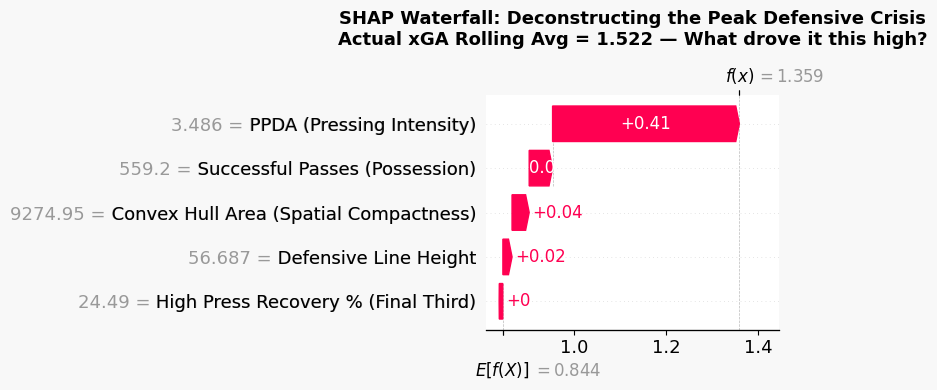


SHAP Smoking Gun analysis complete. Saved 3 capstone figures:
  → Capstone_Fig_SHAP_BarRanking.png
  → Capstone_Fig_SHAP_Beeswarm.png
  → Capstone_Fig_SHAP_Waterfall.png


In [5]:
# Cell 12: SHAP Analysis — The Smoking Gun
# Requires: macro_rf, X_test, y_test from Cell 10
# Answers: Which of the 5 Tactical DNA traits most drove Barcelona's defensive decline?
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 55)
print("  SHAP ANALYSIS — THE SMOKING GUN")
print("  Which Tactical DNA Trait Drives Defensive Decline?")
print("=" * 55)

# Human-readable labels for the capstone
feature_labels = {
    'ppda_rolling':              'PPDA (Pressing Intensity)',
    'def_line_rolling':          'Defensive Line Height',
    'convex_hull_area_rolling':  'Convex Hull Area (Spatial Compactness)',
    'high_turnover_pct_rolling': 'High Press Recovery % (Final Third)',
    'passes_rolling':            'Successful Passes (Possession)'
}

X_test_labeled = X_test.rename(columns=feature_labels)

# ── 1. SHAP VALUES ──────────────────────────────────────────────
explainer = shap.TreeExplainer(macro_rf)
shap_values = explainer.shap_values(X_test)

# ── 2. RANKED BAR CHART — THE HIERARCHY OF TACTICAL DECAY ──────
mean_abs_shap = np.abs(shap_values).mean(axis=0)
ranking = pd.DataFrame({
    'Feature': list(feature_labels.values()),
    'Mean |SHAP|': mean_abs_shap
}).sort_values('Mean |SHAP|', ascending=True)

print("\n  SHAP Feature Ranking — Influence on xGA Rolling Average")
print("  " + "-" * 50)
for _, row in ranking.iloc[::-1].iterrows():
    bar = "█" * int(row['Mean |SHAP|'] * 500)
    print(f"  {row['Feature']:<40s}  {row['Mean |SHAP|']:.5f}  {bar}")
print()
print(f"PRIMARY SMOKING GUN:   {ranking.iloc[-1]['Feature']}")
print(f"SECONDARY DRIVER:      {ranking.iloc[-2]['Feature']}")

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#0f0f1a')

bar_colors = ['#e74c3c' if i == len(ranking) - 1
              else '#e67e22' if i == len(ranking) - 2
              else '#3498db' for i in range(len(ranking))]

bars = ax.barh(ranking['Feature'], ranking['Mean |SHAP|'],
               color=bar_colors, edgecolor='#1a1a2e', height=0.55)

for bar, val in zip(bars, ranking['Mean |SHAP|']):
    ax.text(val + 0.0003, bar.get_y() + bar.get_height() / 2,
            f'{val:.5f}', va='center', ha='left',
            fontweight='bold', fontsize=11, color='white')

ax.annotate('THE SMOKING GUN', xy=(ranking.iloc[-1]['Mean |SHAP|'], len(ranking) - 1),
            xytext=(ranking.iloc[-1]['Mean |SHAP|'] * 0.5, len(ranking) - 1 + 0.4),
            arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=2),
            fontsize=11, color='#e74c3c', fontweight='bold')

ax.set_title(
    "SHAP Feature Importance: The Hierarchy of Barça's Tactical Decay\n"
    "Mean |SHAP| = Average Impact on xGA Rolling Average",
    fontsize=13, fontweight='bold', color='white', pad=12
)
ax.set_xlabel("Mean Absolute SHAP Value", fontsize=12, color='#aaaaaa')
ax.tick_params(colors='white')
ax.grid(True, axis='x', linestyle='--', alpha=0.25, color='#aaaaaa')
for spine in ax.spines.values():
    spine.set_color('#333355')

plt.tight_layout()
plt.savefig("Capstone_Fig_SHAP_BarRanking.png", dpi=300, bbox_inches='tight',
            facecolor='#1a1a2e')
plt.show()

# ── 3. BEESWARM SUMMARY PLOT ────────────────────────────────────
plt.figure(figsize=(12, 7))
shap.summary_plot(shap_values, X_test_labeled, plot_type="dot",
                  color_bar_label="Feature Value (Low → High)",
                  show=False)
ax = plt.gca()
ax.set_title(
    "SHAP Beeswarm: Direction & Magnitude of Each Tactical DNA Feature\n"
    "(Red dot = High Feature Value  |  Blue dot = Low Feature Value)",
    fontsize=13, fontweight='bold', pad=15
)
ax.set_xlabel(
    "SHAP Value — Impact on xGA Rolling Average\n"
    "(→ Positive = More Goals Conceded  |  ← Negative = Fewer Goals Conceded)",
    fontsize=11, fontweight='bold'
)
fig = plt.gcf()
fig.set_facecolor('#f8f8f8')
plt.tight_layout()
plt.savefig("Capstone_Fig_SHAP_Beeswarm.png", dpi=300, bbox_inches='tight')
plt.show()

# ── 4. WATERFALL — WORST DEFENSIVE WINDOW MICRO-CASE STUDY ─────
worst_loc = y_test.values.argmax()
worst_xga = y_test.values[worst_loc]

print(f"\n  Micro-Case Study — Peak Defensive Crisis Window")
print(f"  Actual xGA Rolling Average at this point: {worst_xga:.3f}")
print(f"\n  Tactical State of the Club at that Moment:")
for col, label in feature_labels.items():
    val = X_test.iloc[worst_loc][col]
    print(f"    {label:<45s}: {val:.3f}")

base_val = explainer.expected_value
if hasattr(base_val, '__len__'):
    base_val = float(base_val[0])

exp = shap.Explanation(
    values=shap_values[worst_loc],
    base_values=float(base_val),
    data=X_test.iloc[worst_loc].values,
    feature_names=list(feature_labels.values())
)

plt.figure(figsize=(11, 6))
shap.plots.waterfall(exp, show=False)
ax = plt.gca()
ax.set_title(
    f"SHAP Waterfall: Deconstructing the Peak Defensive Crisis\n"
    f"Actual xGA Rolling Avg = {worst_xga:.3f} — What drove it this high?",
    fontsize=13, fontweight='bold', pad=15
)
fig = plt.gcf()
fig.set_facecolor('#f8f8f8')
plt.tight_layout()
plt.savefig("Capstone_Fig_SHAP_Waterfall.png", dpi=300, bbox_inches='tight')
plt.show()

print("\nSHAP Smoking Gun analysis complete. Saved 3 capstone figures:")
print("  → Capstone_Fig_SHAP_BarRanking.png")
print("  → Capstone_Fig_SHAP_Beeswarm.png")
print("  → Capstone_Fig_SHAP_Waterfall.png")